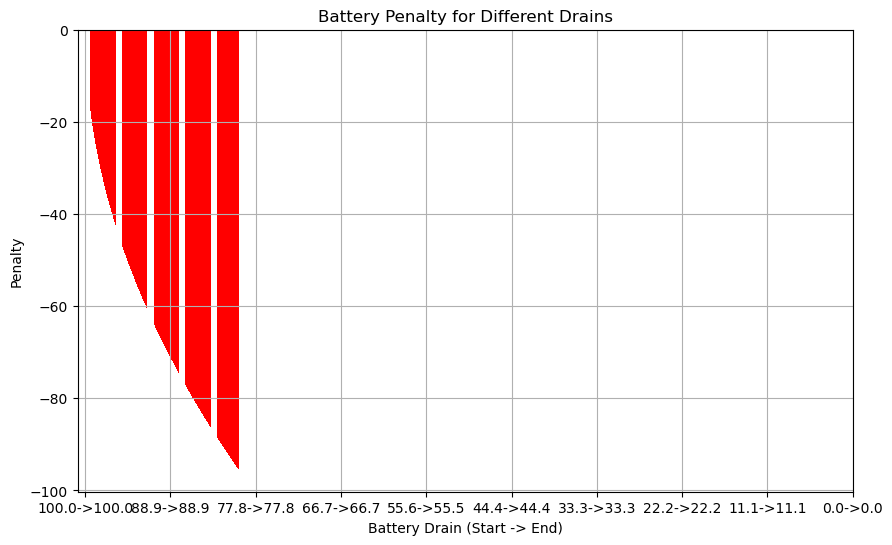

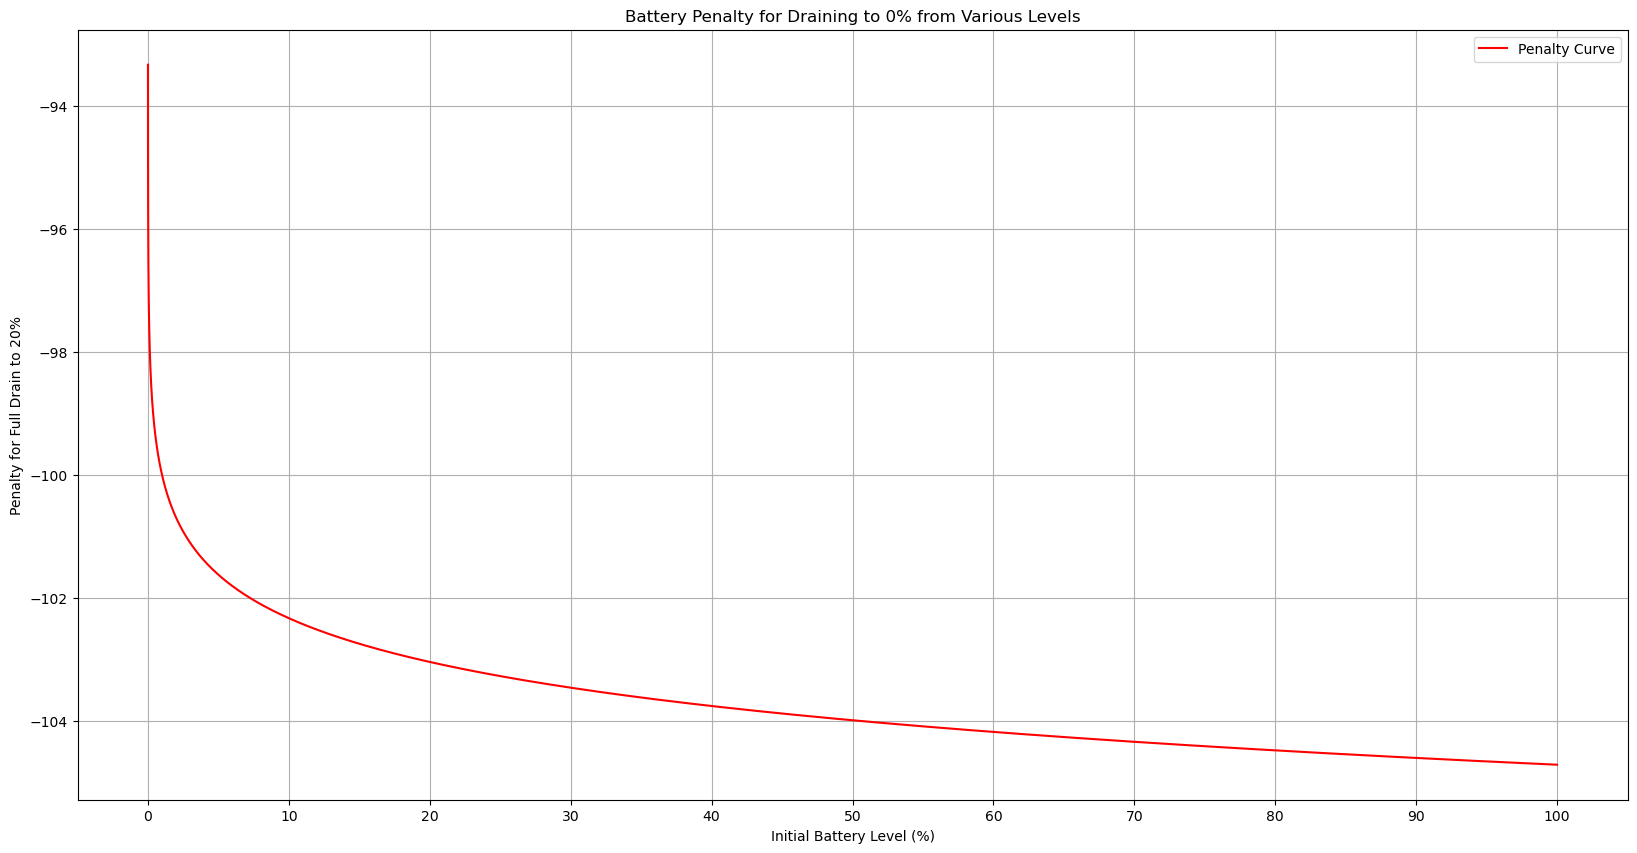

-103.04105579112526


In [20]:
import numpy as np
import matplotlib.pyplot as plt

def penalty_function(b_start, b_end, alpha=100.0, beta=0.5, gamma=0.01):
    """
    Calculate penalty based on initial and final battery levels.

    Parameters:
    - b_start: Initial battery level (%).
    - b_end: Final battery level (%).
    - alpha: Base penalty scaling factor.
    - beta: Exponential scaling factor for low battery levels.
    - gamma: Exponent for battery drain.

    Returns:
    - penalty: The calculated penalty.
    """
    if b_start < b_end:
        raise ValueError("Final battery level must be less than or equal to the initial battery level.")

    # Calculate the percentage of battery drained and apply non-linearity
    battery_drain = (b_start - b_end) ** gamma
    
    # Calculate the exponential penalty factor based on the remaining battery level
    low_battery_factor = ((100 - b_end) / 100) ** beta
    
    # Calculate the total penalty
    penalty = -alpha * battery_drain * low_battery_factor

    return penalty



# Define battery levels for different transitions
num_samples = 10000  # Define the number of samples you want
battery_starts = np.linspace(100, 0.01, num_samples)
battery_ends = np.linspace(99.99, 0, num_samples)
penalties = []

# Calculate penalties for each battery drain scenario
for b_start, b_end in zip(battery_starts, battery_ends):
    penalty = penalty_function(b_start, b_end)

    penalties.append(penalty)    

# Plotting penalties
plt.figure(figsize=(10, 6))
plt.bar([f"{b_start:.1f}->{b_end:.1f}" for b_start, b_end in zip(battery_starts, battery_ends)], penalties, color='red')
plt.xlabel('Battery Drain (Start -> End)')
plt.ylabel('Penalty')
plt.title('Battery Penalty for Different Drains')
plt.grid(True)

# Only plot a subset of labels to prevent overcrowding
plt.xticks(ticks=np.linspace(0, num_samples - 1, 10), labels=[f"{battery_starts[int(i)]:.1f}->{battery_ends[int(i)]:.1f}" for i in np.linspace(0, num_samples - 1, 10)])

plt.show()

# Generate a range of starting battery levels and calculate penalties for draining to 0%
battery_levels = np.arange(100, 0, -0.001)  # Start from 100% down to 0% with 0.1 steps
penalties = []
# Calculate penalties for each level down to 0%
for start_level in battery_levels:
    penalty = penalty_function(start_level, 0)
    # penalty = penalty_function(start_level, 0, alpha=10.0, beta=3.0, gamma=1.5)
    penalties.append(penalty)

# Plotting penalties across battery levels
plt.figure(figsize=(20, 10))
plt.plot(battery_levels, penalties, label='Penalty Curve', color='red')
plt.xlabel('Initial Battery Level (%)')
plt.ylabel('Penalty for Full Drain to 20%')
plt.title('Battery Penalty for Draining to 0% from Various Levels')
plt.grid(True)
plt.xticks(np.arange(0, 101, 10))
plt.legend()
plt.show()

print(penalty_function(20, 0))

In [21]:
def bb (b_end, beta=0.5):
    return ((100 - b_end) / 100) ** beta
step = 0.01
list = np.arange(100, 0, -step)
for i in list:
    print(f"{i}: {(-100 * (bb(i)) * ((step) ** 0.01))}")
# print(-10 * ((0.1) ** 1.5) * 1000)

100.0: -0.0
99.99: -0.9549925860216802
99.97999999999999: -1.350563467117615
99.96999999999998: -1.654095679841142
99.95999999999998: -1.9099851720433605
99.94999999999997: -2.1354283403527923
99.93999999999997: -2.339244543894088
99.92999999999996: -2.5266728865238246
99.91999999999996: -2.70112693423523
99.90999999999995: -2.8649777580650406
99.89999999999995: -3.019951720402789
99.88999999999994: -3.167352085405117
99.87999999999994: -3.308191359682284
99.86999999999993: -3.4432747365891223
99.85999999999993: -3.5732550638023683
99.84999999999992: -3.698670381413522
99.83999999999992: -3.819970344086721
99.82999999999991: -3.937535303849147
99.81999999999991: -4.051690401352845
99.8099999999999: -4.162716174299078
99.7999999999999: -4.2708566807055846
99.78999999999989: -4.376325813565976
99.77999999999989: -4.479312275990622
99.76999999999988: -4.579983548572708
99.75999999999988: -4.678489087788176
99.74999999999987: -4.774962930108401
99.73999999999987: -4.869525831460984
99.7299

In [22]:
import numpy as np

# Initialize parameters
b_start = 100
b_end = 100
step_size = 9.424083754831283e-11
scale = 10**9
alpha = 1
gamma = 2
beta = 1

# Function to calculate penalty
def penalty(b_start, b_end, alpha, gamma, beta, scale):
    return -alpha * ((b_start - b_end) * scale)**gamma * ((100 - b_end) / 100)**beta

# Simulate the battery draining process
iterations = 0
battery_level = b_start
penalties = []

while battery_level > 0:
    b_end = battery_level - step_size
    penalties.append(penalty(battery_level, b_end, alpha, gamma, beta, scale))
    battery_level -= step_size * scale
    iterations += 1

iterations, np.sum(penalties)

(1062, -4.715483535641486)